# Introduction to Computational Physics: Problem Set 8
Tutorial: Chun Ming Yip (Group 3)

Document created by: Vencel Szabó, Finn Zeumer

In [67]:
from numpy.linalg import solve
import numpy as np
# import astropy.units as u
import matplotlib.pyplot as plt


In [68]:
# Setting Constans
G = 1
M_1 = 1
M_2 = 1

$\frac{d\vec{s}}{dt} = \vec{w}$

$\frac{d\vec{r}}{dt} = -\frac{\vec{s}}{s^3}$

where

$\vec{s} = \vec{v}/R_0, \qquad R_0 \text{ Mean Seperation }$

$\vec{\omega} = \vec{v}/v_0, \qquad \text{where } v_0 = \left(\dfrac{GM}{R_0}\right)$

$\tau = t/T_0, \qquad \text{where } T_0 = R_0/v_0 = \left( \dfrac{R_0^3}{GM} \right)^{1/2}$

# 1.1

In [69]:
def norm_r(r, R_0:float=1.0):
    return r/R_0

In [70]:
def norm_v(v, m:float = 1, R_0:float = 1.0):
    return v / np.sqrt(G * m / R_0)

In [71]:
def norm_t(t, R_0:float = 1, m:float = 1.0):
    return t / np.sqrt(R_0**2 / G / m)

The speed for each body is
$$w_0 = 1,$$
since we set the gravitational and the centripetal force equal at all point. 

The accerleration of the centipetal force is hence 
$$a_c = w_0^2/r.$$
And the gravitational acceleration
$$a_g = -\vec s / s^3 = GM/r^2 =w_0^2/r$$

Actually, we are just interested in the magnitude:
$$a_g = 1/ s^2$$

For an perfect ciruclar trajectory we need
$$a_g \overset{!}=a_c$$
thus
$$-1/ s^2 = w_0^2/r$$

With $s=1, r=1$ we get
$$w_0 = \sqrt{1} = 1$$


# 1.2 Euler's Method

We have a ODE of first order:
$$\frac{dy}{d\tau} = f(y,\tau)$$

with the initial conditions
$$y(0) = s_0$$
and
$$y'(0) = w_0$$

## Approximate solution 
$$\bar{y}_{i+1} = \bar{y}_i + h\cdot f(\bar{y}_i, \tau)$$

where the bar indicateds that we jsut have an approximation and 
$$h=t_{i+1}-t_i = \frac{a-b}{N} = \Delta \tau$$
is the stepsize/gridsize. The intervall is $[a,b]$ and the mesh contains $N$ cells/points.

In [72]:
# INITIAL CONDITIONS AND CONSTANTS
#Timesteps
delta_tau = 0.01
# total time
t_tot = 10
# steps
N_steps = int(t_tot/delta_tau)

# INITIAL CONDITIONS
# The starting seperation y(0)
s_0 = [1,0]
# the sarting velocity y'(0)
w_0 = [0,1] # must be perpendicular to s_0

In [73]:
def eulerSolving_twoBodyTwoD(
        s_0:np.ndarray = np.array([1,0]), 
        w_0:np.ndarray = np.array([0,1]), 
        total_time:float = 20,
        time_step:float = 0.01
        ):
    '''
    Method defining dy/dtau = f(y)

    params
    ______
    s_0 : np.ndarray (1 x 2)
        initial seperation of the two bodys
    w_0 : np.ndarray (1 x 2)
        inital relativ velocity
    total_time : float
        total time that the simulation should run through
    time_step : float
        stepsize/intervall for each step until the total time is reached. (Steps N = total:time/time_step)

    returns
    _______


    '''
    # calculating the stepzise by given parameters
    steps = int(total_time/time_step)
    
    # Initialize storage
    s_history = np.zeros((steps, 4))

    # Calculating distance between the two bodies
    dist = np.sqrt(np.sum(np.square(s_0)))
    if dist <= 1e-15:
        raise ValueError('The distance between the bodies must be lagrer than 0.')
    
    # Calculationg the accerleration factor
    acc_fac = -1 / (dist**3)

    # Summerizing inital conditions
    def calc_step(y):
        s = y[0:2]
        w = y[2:4]

        ds_dtau = w
        dw_dtau = acc_fac * s

        # Finial value to return
        y_temp = np.concatenate([ds_dtau, dw_dtau], axis=0)
        return y_temp
    

    # Calculating starting position
    y_start = np.concatenate([s_0, w_0], axis=0)
    y_0 = calc_step(y_start)
    s_history[0] = y_0

    # loop to get the results for every step
    for i in range(1, steps):
        current_y = s_history[i-1]

        # Calcuate derivertive f(y) = dy/dt
        dy_dt = calc_step(current_y)

        # Euler Step: y_{n+1} = y_n + dt * f(y_n)
        s_history[i] = current_y + time_step * dy_dt


    return s_history

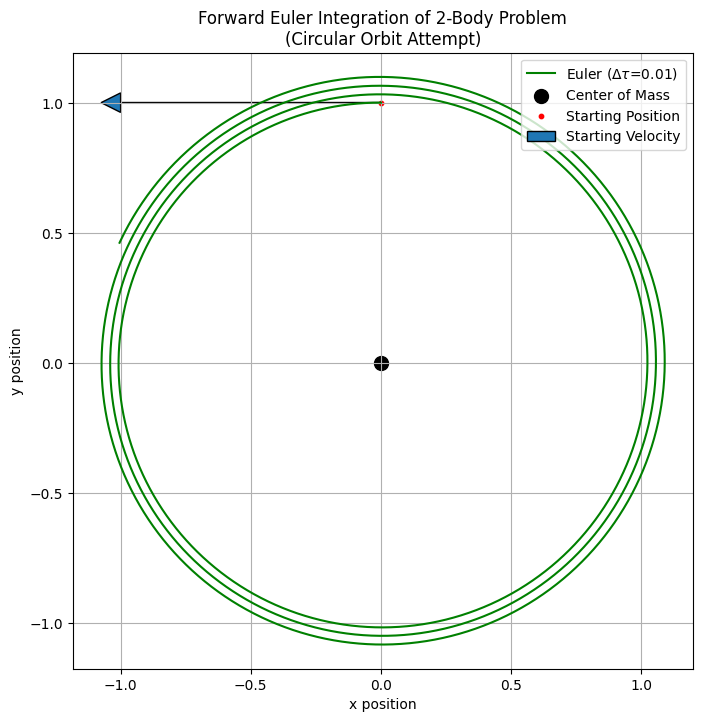

In [74]:
params = eulerSolving_twoBodyTwoD()
x_pos = params[:,0]
y_pos = params[:,1]
x_velo = params[:,2]
y_velo = params[:,3]

# --- Plotting the Result (Task 2) ---
plt.figure(figsize=(8, 8))
ax = plt.axes()
ax.plot(
    x_pos,
    y_pos, 
    label=fr'Euler ($\Delta\tau$={delta_tau})', 
    color='green'
    )

# Plot inital conditions and CoM
ax.scatter([0], [0], color='black', s=100, label='Center of Mass')
ax.scatter(x_pos[0], y_pos[0], color='red', s=10, label='Starting Position')
ax.arrow(x_pos[0], y_pos[0], x_velo[0], y_velo[0], head_width=0.075, head_length=0.075, label='Starting Velocity')

plt.title('Forward Euler Integration of 2-Body Problem\n(Circular Orbit Attempt)')
plt.xlabel('x position')
plt.ylabel('y position')
plt.axis('equal') 
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

## Spiraling
Clearly to see is a spiraling motion -- not at all a true circle. A change in orbit of this kind can physically only be explained by a change of energy in the system. Which of course, is not what we expect/want. Rather we would expect perfect circular motion (for the specific inital conidtions). So, why do we have a cange in energy? 

The reason is quit simple to find, since it is not a physical issue but a issue in the algorithm (forward Euler's Method (explicit)). As we discussed in the lectur, the forward Euler method is NOT sympetic and thus does not conserve energy.

# 1.3

In [75]:
def vecLength(x):
    return np.sqrt(np.sum(x**2))

In [76]:
def LaplaceRungeLenz(
        v:np.ndarray[float] = np.array([0,1,0]), 
        r:np.ndarray[float] = np.array([1,0,0]),
        M:float = 2,
        reduced_mass:float = 1,
        normalize:bool = True
        ):
    '''
    Method to calculate the eccentrity vector of a orbit. It is only defined in a vector space R^3
    since we use the cross product in here.

    params
    ______
    v : 3darray
        velocity vector
    
    r : 3darray
        position vector from CoM to the partical

    m : float (Optional)
        Total mass in the system

    reduced_mass : float (optional)
        The reduced mass. 
    
    normalize : bool (optional)
        Rather you want to dimensionalize and normalize your values
        
    returns
    _______
    eccentricity Vector, eccentricity
    '''
    
    if normalize:
        w = norm_v(v, M)
        s = norm_r(r, M)

        # Normalization on j
        L = np.cross(s, reduced_mass*w)
        j = L / reduced_mass

        e = np.cross(w, j) / (G * M) - s / vecLength(s)
        eccentricity = vecLength(e)
        return e, eccentricity
        

    L = np.cross(r, reduced_mass * v)
    j = L / reduced_mass

    e = np.cross(v, j) / (G * M) - r / vecLength(r)
    eccentricity = vecLength(e)

    return e, eccentricity

In [77]:
def laplace_runge_lenz(s, w):
    """
    SIMPLEFIED VERSION
    Calculate the LRL vector (eccentricity vector) for the dimensionless 2-body problem.
    
    Parameters:
    s : array, shape (3,)
        Dimensionless separation vector
    w : array, shape (3,)  
        Dimensionless velocity vector
        
    Returns:
    A : array, shape (3,)
        LRL vector
    e : float
        Eccentricity (magnitude of LRL)
    """
    s = np.array(s)
    w = np.array(w)
    
    # Distance
    s_mag = np.linalg.norm(s)
    
    # Prevent division by zero
    if s_mag == 0:
        raise ValueError("Position vector cannot be zero")
    
    # Unit vector s_hat
    s_hat = s / s_mag
    
    # Angular momentum (per unit reduced mass, h = s x w)
    h = np.cross(s, w)
    
    # LRL vector: e = (w x h) - s_hat
    A = np.cross(w, h) - s_hat
    
    # Eccentricity is the magnitude
    e = np.linalg.norm(A)
    
    return A, e

Some Example:

In [78]:
example_speed = np.array([1,2,0])
example_specific_angular_momentum = np.array([0,0,5])
example_radius = np.array([1,-2,0])


e = LaplaceRungeLenz(example_speed, example_radius, normalize=True)
print(f'Eccentricity: {e[1]:.2f}')

Eccentricity: 0.68


In [79]:
params = eulerSolving_twoBodyTwoD()
x_pos = params[:,0][0]
y_pos = params[:,1][0]
x_velo = params[:,2][0]
y_velo = params[:,3][0]

example_radius = np.array([x_pos,y_pos,0])
example_speed = np.array([x_velo,y_velo,0])


e = LaplaceRungeLenz(example_speed, example_radius, normalize=True)
print(f'Eccentricity: {e[1]:.2f}')

Eccentricity: 0.88


# 1.4

-1.0
[-1. -0.  0.]


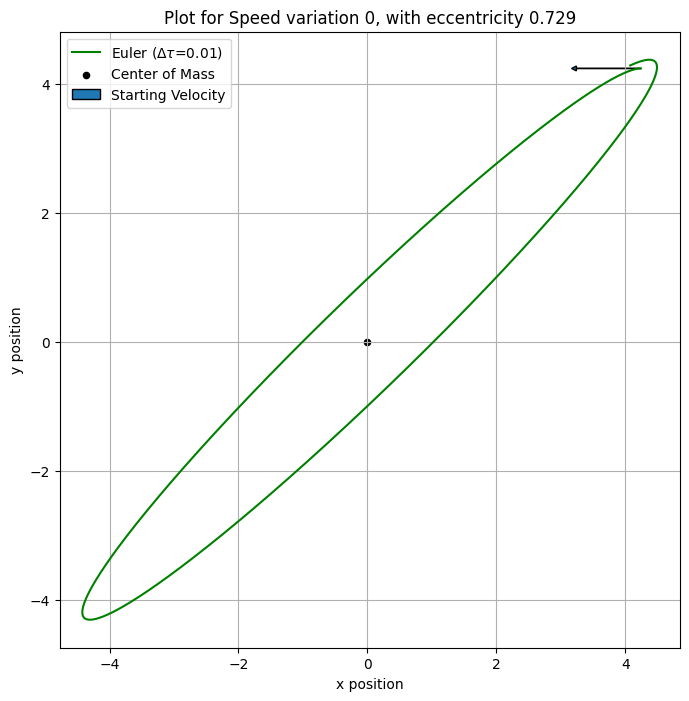

-1.0
[-1. -0.  0.]


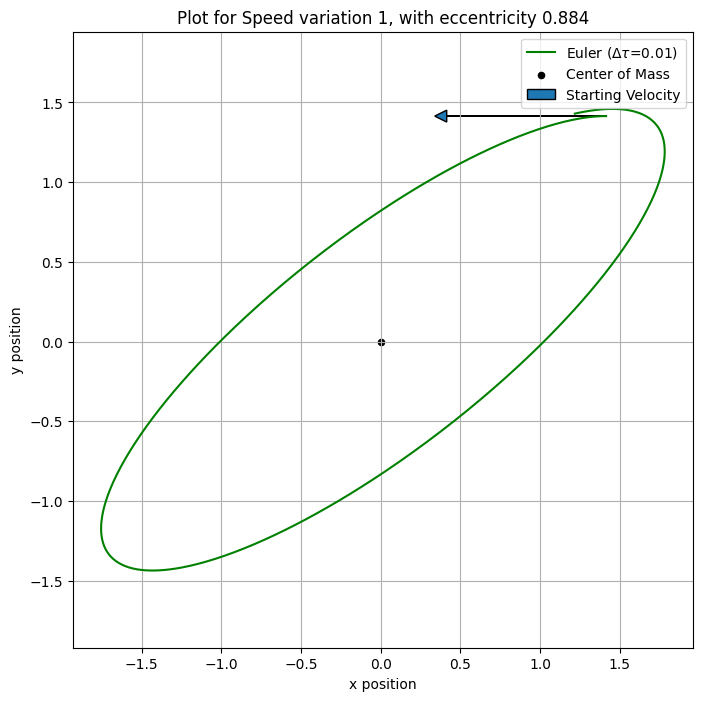

-1.0
[-1. -0.  0.]


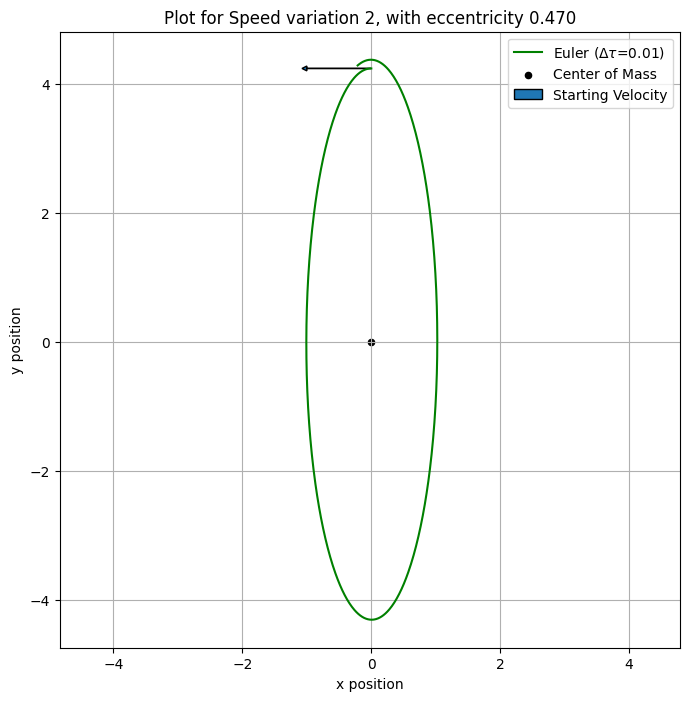

-1.0
[-1. -0.  0.]


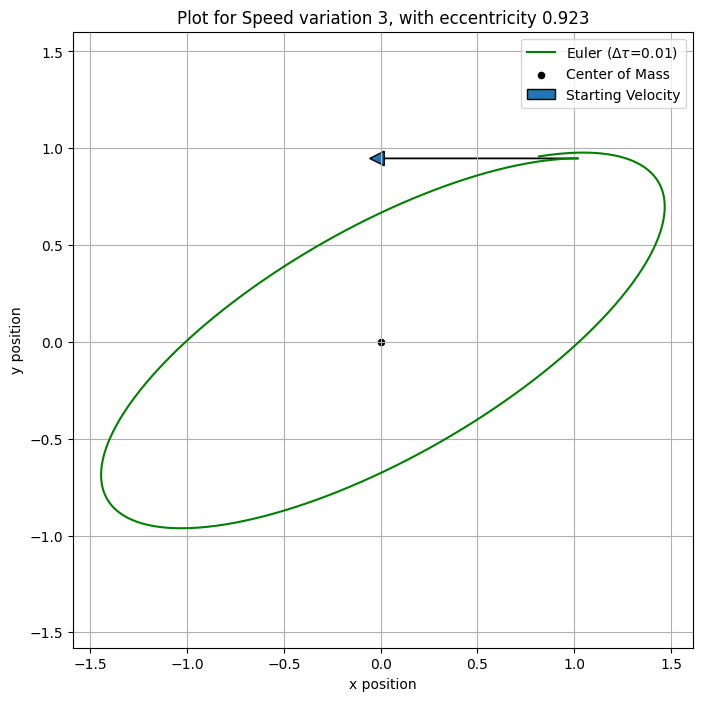

-1.0
[-1. -0.  0.]


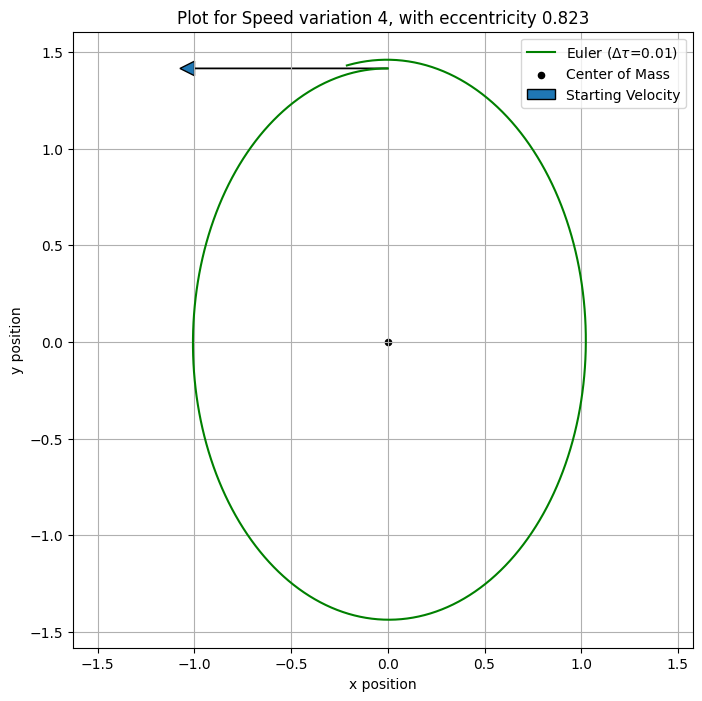

In [80]:
# Variation of speeds
velocit_vari = np.array([[3,3],[1,1],[0,3],[0.72,0.67], [0,1]]) * np.sqrt(2)


diffrent_velocs = []
for i in velocit_vari:
    diffrent_velocs.append(eulerSolving_twoBodyTwoD(w_0 = i, total_time=6.5))

for i in range (len(velocit_vari)):
    x_pos = diffrent_velocs[i][:,0]
    y_pos = diffrent_velocs[i][:,1]
    x_velo = diffrent_velocs[i][:,2]
    y_velo = diffrent_velocs[i][:,3]

    print(x_velo[0])

    inital_velo = np.array([x_velo[0], y_velo[0], 0], float)
    print((inital_velo))

    # --- Plotting the Result (Task 2) ---
    plt.figure(figsize=(8, 8))
    ax = plt.axes()
    ax.plot(
        x_pos,
        y_pos, 
        label=fr'Euler ($\Delta\tau$={delta_tau})', 
        color='green'
        )

    # Plot inital conditions and CoM
    ax.scatter([0], [0], color='black', s=20, label='Center of Mass')
    # ax.scatter(x_pos[0], y_pos[0], color='red', s=10, label='Starting Position')
    ax.arrow(x_pos[0], y_pos[0], x_velo[0], y_velo[0], head_width=0.075, head_length=0.075, label='Starting Velocity')

    e, eccent = LaplaceRungeLenz(v=inital_velo, r=np.array([x_pos[0],y_pos[0],0]))


    plt.title(f'Plot for Speed variation {i}, with eccentricity {eccent:.3f}')
    plt.xlabel('x position')
    plt.ylabel('y position')
    plt.axis('equal') 
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

In [81]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# # Define velocity ranges for smooth animation
# v_x_values = np.linspace(0.1, 2.0, 40)  # 40 steps for x component
# v_y_start = 1.0
# v_y_end = 2.0
# v_y_values = np.linspace(v_y_start, v_y_end, 40)  # 40 steps for y component

# # Create combined frames (first phase: vary x, second phase: vary y)
# frames_list = []
# for vx in v_x_values:
#     frames_list.append((vx, v_y_start))  # Phase 1: v_x varies, v_y fixed

# for vy in v_y_values[1:]:  # Skip first to avoid duplicate
#     frames_list.append((v_x_values[-1], vy))  # Phase 2: v_y varies, v_x fixed max

# print(f"Total animation frames: {len(frames_list)}")

# # Setup figure with dual panels
# fig = plt.figure(figsize=(14, 6))

# # Left panel: Current orbit
# ax1 = fig.add_subplot(1, 2, 1)
# ax1.set_xlim(-3, 3)
# ax1.set_ylim(-3, 3)
# ax1.set_aspect('equal')
# ax1.grid(True, alpha=0.3)
# ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
# ax1.axvline(0, color='gray', linestyle='-', linewidth=0.5)
# ax1.scatter([0], [0], color='black', s=80, marker='o', zorder=3, label='CoM')
# current_orbit, = ax1.plot([], [], 'b-', linewidth=1.5, label='Current Orbit')
# velocity_arrow = None
# phase_text = ax1.text(0.95, 0.95, '', transform=ax1.transAxes, fontsize=10,
#                       verticalalignment='top', horizontalalignment='right',
#                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# # Right panel: All accumulated orbits
# ax2 = fig.add_subplot(1, 2, 2)
# ax2.set_xlim(-3, 3)
# ax2.set_ylim(-3, 3)
# ax2.set_aspect('equal')
# ax2.grid(True, alpha=0.3)
# ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
# ax2.axvline(0, color='gray', linestyle='-', linewidth=0.5)
# ax2.scatter([0], [0], color='black', s=80, marker='o', zorder=3, label='CoM')
# all_orbits_lines = []  # Store references to all orbits
# progress_line, = ax2.plot([], [], 'ro', markersize=5, label='Progression')

# def init():
#     """Initialize animation"""
#     current_orbit.set_data([], [])
#     if velocity_arrow is not None:
#         try:
#             velocity_arrow.remove()
#         except:
#             pass
#     phase_text.set_text('')
#     return current_orbit,

# def update(frame):
#     """Update for each frame - animate through velocity parameter space"""
#     global velocity_arrow
    
#     # Clear previous arrow
#     if velocity_arrow is not None:
#         try:
#             velocity_arrow.remove()
#         except:
#             pass
    
#     # Get current velocity
#     vx, vy = frames_list[frame]
    
#     # Simulate orbit
#     result = eulerSolving_twoBodyTwoD(w_0=np.array([vx, vy]), total_time=6.5)
#     x_pos = result[:, 0]
#     y_pos = result[:, 1]
    
#     # Update left panel - current orbit
#     current_orbit.set_data(x_pos, y_pos)
    
#     # Add velocity arrow (scaled for visibility)
#     velocity_arrow = ax1.arrow(x_pos[0], y_pos[0], x_velo[0]*0.5, y_velo[0]*0.5,
#                                head_width=0.1, head_length=0.1, fc='red', ec='red',
#                                length_includes_head=True, zorder=4)
    
#     # Calculate eccentricity
#     initial_velo = np.array([result[0, 2], result[0, 3], 0], float)
#     _, eccent = LaplaceRungeLenz(v=initial_velo, r=np.array([x_pos[0], y_pos[0], 0]))
    
#     # Determine orbital type
#     if eccent >= 1.0:
#         orbit_type = "UNBOUND (Hyperbolic)"
#         color = 'orange'
#     elif eccent >= 0.9:
#         orbit_type = "Near-Parabolic"
#         color = 'yellow'
#     else:
#         orbit_type = "BOUND (Elliptical)"
#         color = 'blue'
    
#     # Update text info
#     phase_info = f"Frame: {frame+1}/{len(frames_list)}\n"
#     phase_info += f"Velocity: (v_x={vx:.2f}, v_y={vy:.2f})\n"
#     phase_info += f"Eccentricity: {eccent:.3f}\n"
#     phase_info += f"Type: {orbit_type}"
    
#     phase_text.set_text(phase_info)
#     phase_text.get_bbox_patch().set_facecolor(color)
    
#     # Update right panel - accumulate all orbits
#     # Add new orbit line with fading transparency based on progression
#     alpha = (frame + 1) / len(frames_list)  # Progressive opacity
#     orbit_line = ax2.plot(x_pos, y_pos, '-', color='blue', 
#                           linewidth=0.8, alpha=alpha*0.8)[0]
#     all_orbits_lines.append(orbit_line)
    
#     # Mark current starting point
#     progress_line.set_data([x_pos[0]], [y_pos[0]])
    
#     return current_orbit, phase_text, progress_line

# # Create animation
# ani = FuncAnimation(fig, update, frames=len(frames_list),
#                    init_func=init, blit=False, interval=150, repeat=True)

# plt.tight_layout()
# # plt.show()

# # # Display in Jupyter
# # HTML(ani.to_jshtml())

# # Optional: Save as GIF or MP4
# ani.save('two_body_smooth_animation.gif', writer=PillowWriter(fps=5))

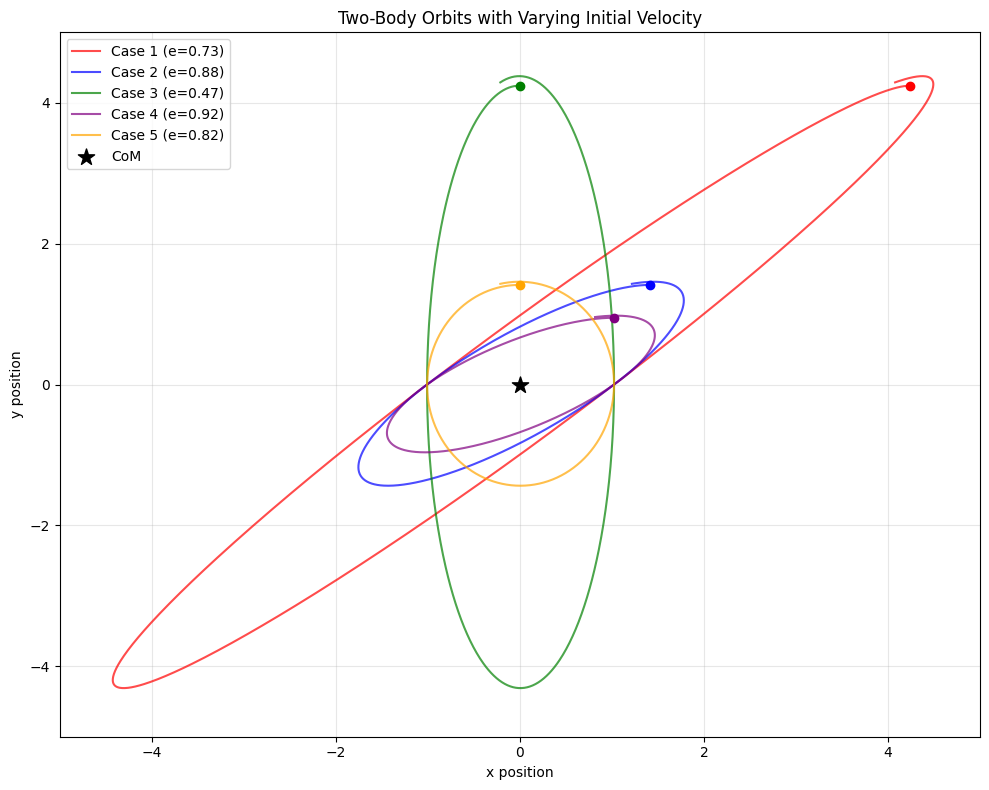

In [82]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i, v_init in enumerate(velocit_vari):
    result = eulerSolving_twoBodyTwoD(w_0=v_init, total_time=6.5)
    
    x_pos = result[:, 0]
    y_pos = result[:, 1]
    
    # Calculate eccentricity for labeling
    initial_velo = np.array([result[0, 2], result[0, 3], 0], float)
    _, eccent = LaplaceRungeLenz(v=initial_velo, r=np.array([x_pos[0], y_pos[0], 0]))
    
    label_str = f'Case {i+1} (e={eccent:.2f})'
    ax.plot(x_pos, y_pos, color=colors[i], linewidth=1.5, alpha=0.7, label=label_str)
    
    # Mark starting point
    ax.plot(x_pos[0], y_pos[0], 'o', color=colors[i], markersize=6)

# Center of mass
ax.scatter([0], [0], color='black', s=150, marker='*', zorder=5, label='CoM')

ax.set_xlabel('x position')
ax.set_ylabel('y position')
ax.set_title('Two-Body Orbits with Varying Initial Velocity')
# ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.xlim(-5,5)
plt.ylim(-5,5)

plt.tight_layout()
plt.show()

# 1.5

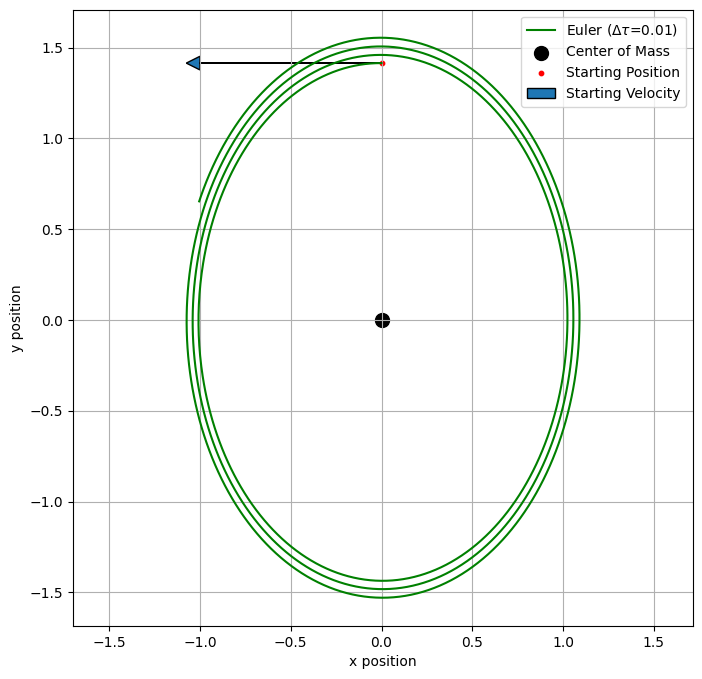

In [83]:
params = eulerSolving_twoBodyTwoD(w_0=np.array([0, np.sqrt(2)]))
x_pos = params[:,0]
y_pos = params[:,1]
x_velo = params[:,2]
y_velo = params[:,3]

# --- Plotting the Result (Task 2) ---
plt.figure(figsize=(8, 8))
ax = plt.axes()
ax.plot(
    x_pos,
    y_pos, 
    label=fr'Euler ($\Delta\tau$={delta_tau})', 
    color='green'
    )

# Plot inital conditions and CoM
ax.scatter([0], [0], color='black', s=100, label='Center of Mass')
ax.scatter(x_pos[0], y_pos[0], color='red', s=10, label='Starting Position')
ax.arrow(x_pos[0], y_pos[0], x_velo[0], y_velo[0], head_width=0.075, head_length=0.075, label='Starting Velocity')

plt.title('')
plt.xlabel('x position')
plt.ylabel('y position')
plt.axis('equal') 
plt.grid(True)
plt.legend(loc='upper right')
plt.show()

# 1.6

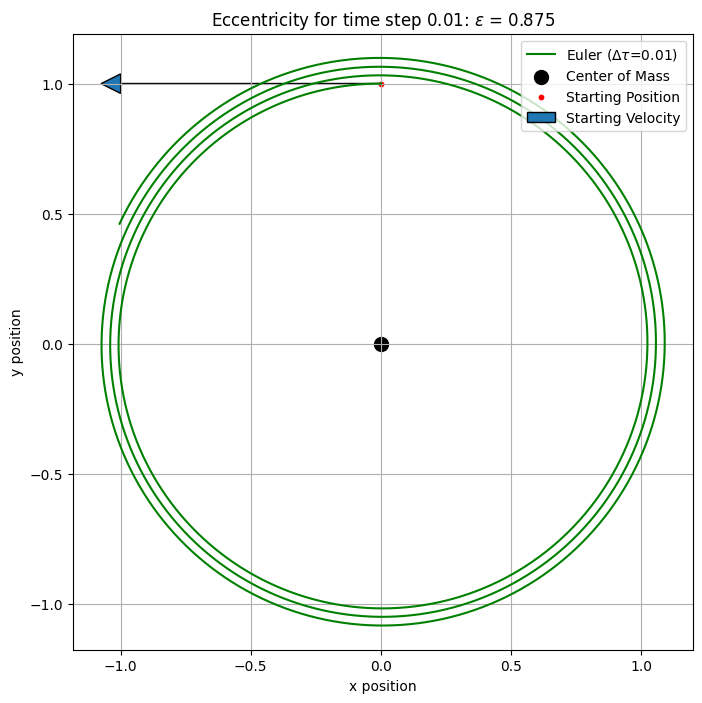

Eccentricity 0.01 = 0.875


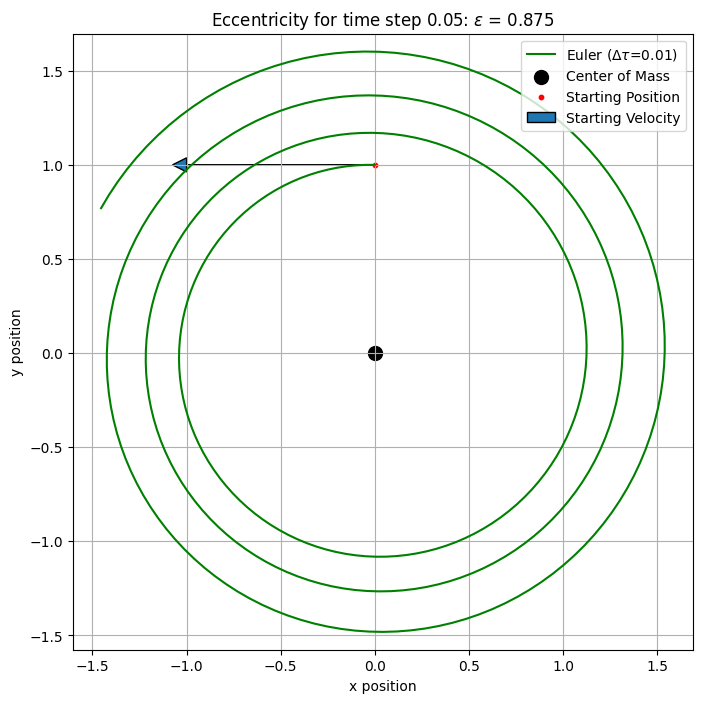

Eccentricity 0.05 = 0.875


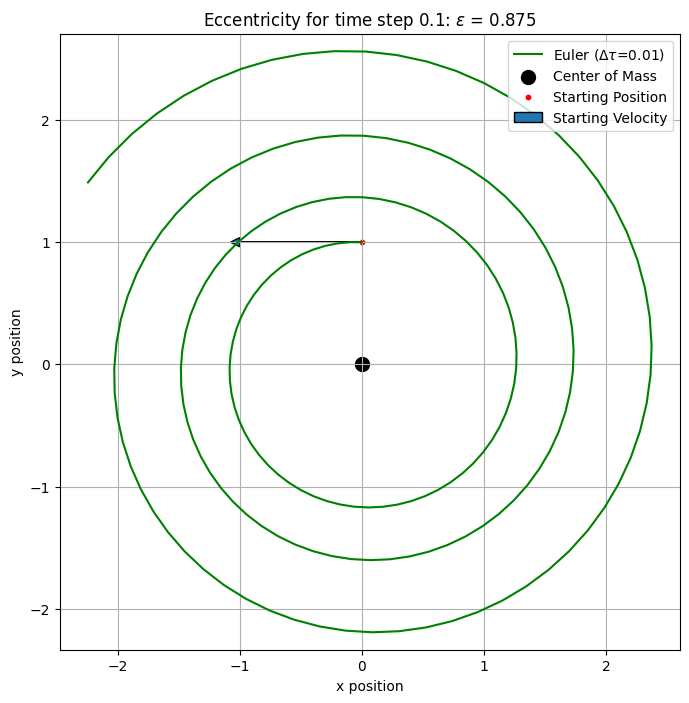

Eccentricity 0.1 = 0.875


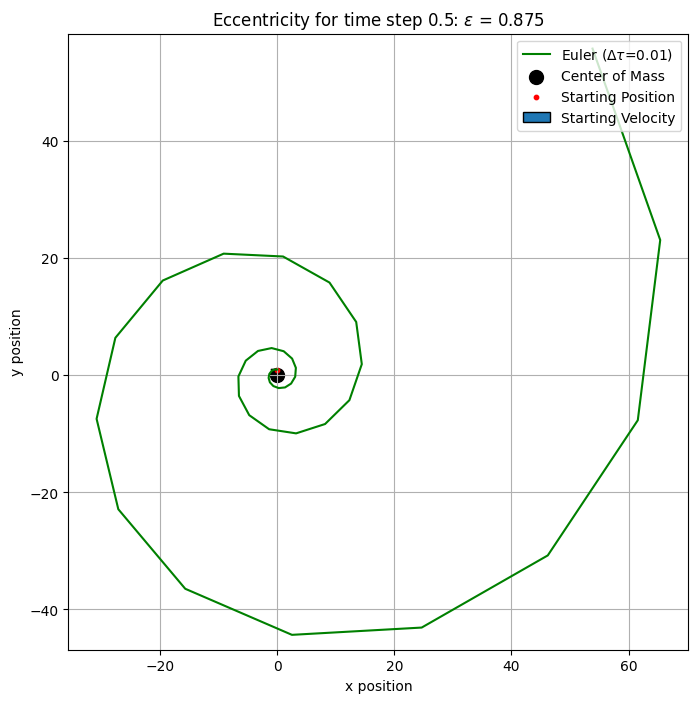

Eccentricity 0.5 = 0.875


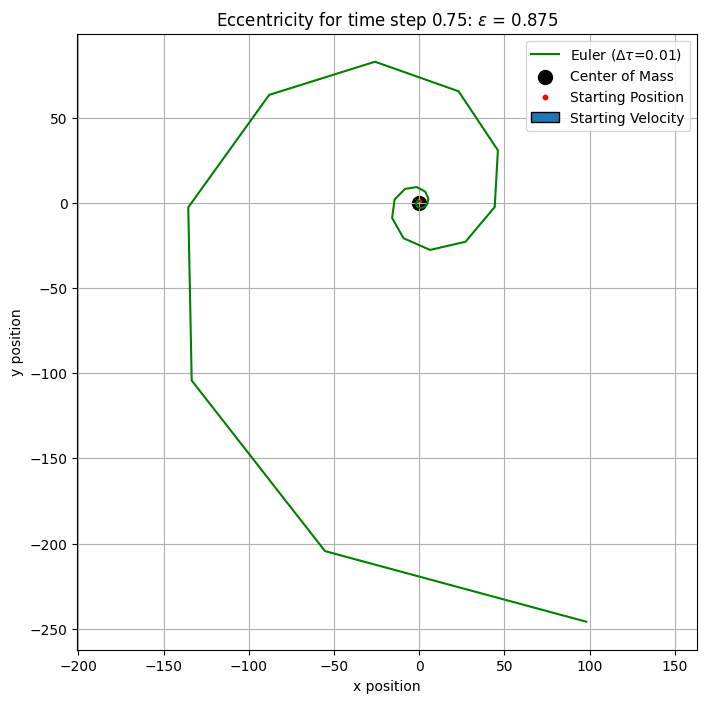

Eccentricity 0.75 = 0.875


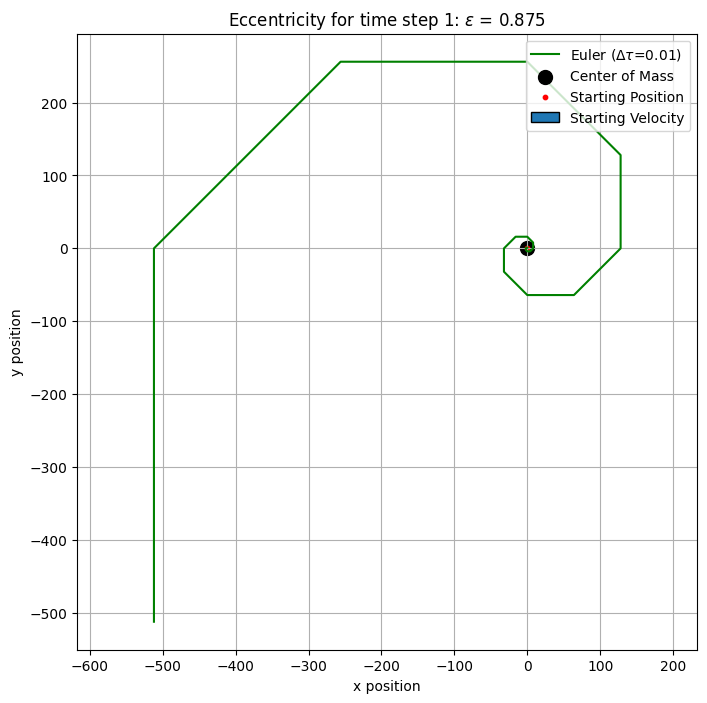

Eccentricity 1 = 0.875


In [97]:
t_steps = [0.01, 0.05, 0.1, 0.5, 0.75, 1]


for i in t_steps:
    params = eulerSolving_twoBodyTwoD(time_step=i)
    x_pos = params[:,0]
    y_pos = params[:,1]
    x_velo = params[:,2]
    y_velo = params[:,3]

    # --- Plotting the Result (Task 2) ---
    plt.figure(figsize=(8, 8))
    ax = plt.axes()
    ax.plot(
        x_pos,
        y_pos, 
        label=fr'Euler ($\Delta\tau$={delta_tau})', 
        color='green'
        )

    # Plot inital conditions and CoM
    ax.scatter([0], [0], color='black', s=100, label='Center of Mass')
    ax.scatter(x_pos[0], y_pos[0], color='red', s=10, label='Starting Position')
    ax.arrow(x_pos[0], y_pos[0], x_velo[0], y_velo[0], head_width=0.075, head_length=0.075, label='Starting Velocity')

    plt.title(fr'Eccentricity for time step {i}: $\epsilon$ = {ecc:.3f}')
    plt.xlabel('x position')
    plt.ylabel('y position')
    plt.axis('equal') 
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.show()

    pos=np.array([x_pos[0],y_pos[0],0])
    velo = np.array([x_velo[0],y_velo[0],0])
    _, ecc = LaplaceRungeLenz(velo,pos)

    print(f'Eccentricity {i} = {ecc:.3f}')

Orbits clearly open, but eccentricities stay the same, since they are only dependend in this code on the inital conditions


# 1.7 Leap Forg

In [98]:
def LeaoFrog():
    return